In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('zomato_8000_records.csv', lineterminator ='\n')

In [3]:
df.head()

,Name,Online,book_table,rate,votes,approx_cost(for two people),listed_in(type)\r
0,Customer_1,No,Yes,1.4,1510,2408,Quick Bites\r
1,Customer_2,No,No,1.3,175,1255,Quick Bites\r
2,Customer_3,Yes,Yes,3.2,3124,1272,Cafe\r
3,Customer_4,Yes,No,3.9,1690,1077,Cafe\r
4,Customer_5,No,No,2.6,3000,1999,Buffet\r


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         8000 non-null   str    
 1   Online                       8000 non-null   str    
 2   book_table                   8000 non-null   str    
 3   rate                         8000 non-null   float64
 4   votes                        8000 non-null   int64  
 5   approx_cost(for two people)  8000 non-null   int64  
             8000 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 437.6 KB


In [5]:
df.describe()

,rate,votes,approx_cost(for two people)
count,8000.000000,8000.000000,8000.000000
mean,3.003687,2507.476875,1606.193375
std,1.167848,1439.012331,809.388536
min,1.000000,1.000000,200.000000
25%,2.000000,1288.750000,901.000000
50%,3.000000,2529.000000,1614.500000
75%,4.000000,3737.000000,2306.000000
max,5.000000,5000.000000,3000.000000


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df = df.apply(lambda col: col.astype(str).str.strip())

In [8]:
df['rate'] = df['rate'].astype(float)
df['votes'] = df['votes'].astype(int)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(int)

In [9]:
print(list(df.columns))

['Name', 'Online', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']


# Visualisation of data

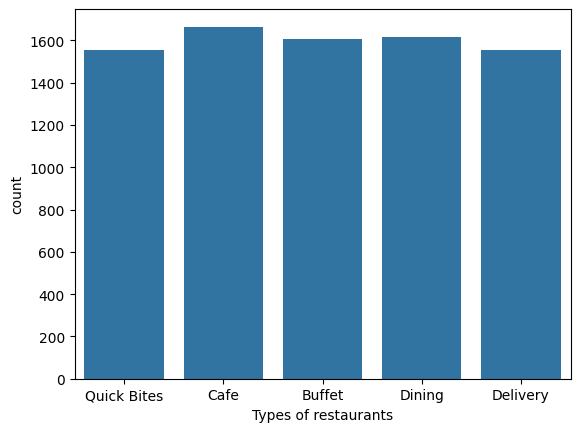

In [12]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Types of restaurants")
plt.show()

- The majority of orders from the restaurants are for cafes.

In [13]:
df.head()

,Name,Online,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Customer_1,No,Yes,1.4,1510,2408,Quick Bites
1,Customer_2,No,No,1.3,175,1255,Quick Bites
2,Customer_3,Yes,Yes,3.2,3124,1272,Cafe
3,Customer_4,Yes,No,3.9,1690,1077,Cafe
4,Customer_5,No,No,2.6,3000,1999,Buffet


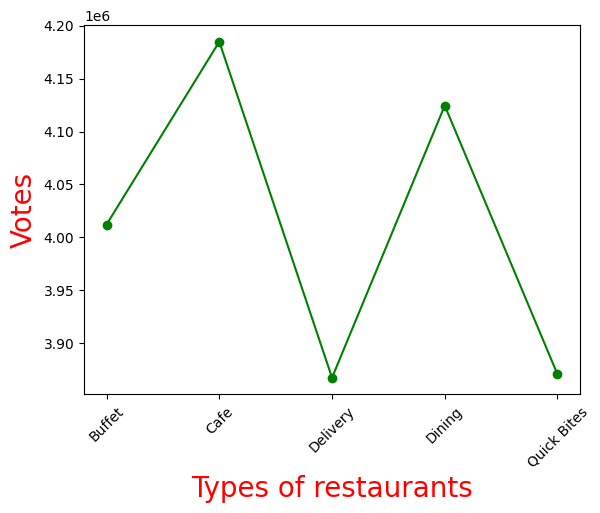

In [18]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()

result = pd.DataFrame({'votes': grouped_data})

plt.plot(result.index, result['votes'], color="green", marker="o")

plt.xlabel("Types of restaurants", color="red", size=20)
plt.ylabel("Votes", color="red", size=20)

plt.xticks(rotation=45)
plt.show()

- The maximum number of votes is given to cafes.

In [19]:
df.head()

,Name,Online,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Customer_1,No,Yes,1.4,1510,2408,Quick Bites
1,Customer_2,No,No,1.3,175,1255,Quick Bites
2,Customer_3,Yes,Yes,3.2,3124,1272,Cafe
3,Customer_4,Yes,No,3.9,1690,1077,Cafe
4,Customer_5,No,No,2.6,3000,1999,Buffet


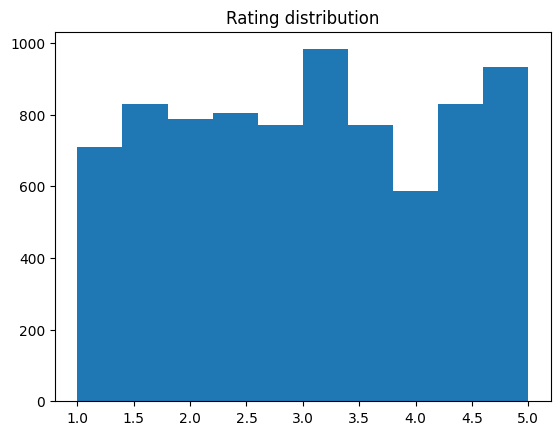

In [25]:
plt.hist(df['rate'], bins = 10)
plt.title("Rating distribution")
plt.show()

- The maximum rating lies between 3.0 and 3.5.

In [22]:
df.head()

,Name,Online,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Customer_1,No,Yes,1.4,1510,2408,Quick Bites
1,Customer_2,No,No,1.3,175,1255,Quick Bites
2,Customer_3,Yes,Yes,3.2,3124,1272,Cafe
3,Customer_4,Yes,No,3.9,1690,1077,Cafe
4,Customer_5,No,No,2.6,3000,1999,Buffet


In [26]:
df[df['approx_cost(for two people)'] == df['approx_cost(for two people)'].max()]

,Name,Online,book_table,rate,votes,approx_cost(for two people),listed_in(type)
4406,Customer_4407,No,No,4.4,1704,3000,Cafe
4846,Customer_4847,Yes,No,4.6,3879,3000,Quick Bites
7939,Customer_7940,Yes,No,2.3,1187,3000,Dining


# The graph:

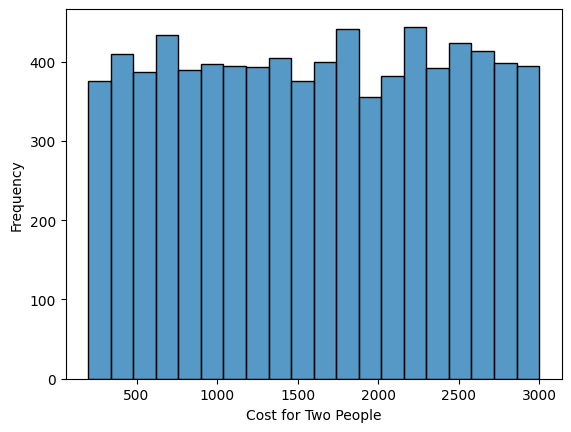

In [33]:
sns.histplot(couple_data, bins=20)

plt.xlabel("Cost for Two People")
plt.ylabel("Frequency")

plt.show()

- The maximum amount spent on orders done by the couples lies between 2000 and 2500.

In [34]:
df.head()

,Name,Online,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Customer_1,No,Yes,1.4,1510,2408,Quick Bites
1,Customer_2,No,No,1.3,175,1255,Quick Bites
2,Customer_3,Yes,Yes,3.2,3124,1272,Cafe
3,Customer_4,Yes,No,3.9,1690,1077,Cafe
4,Customer_5,No,No,2.6,3000,1999,Buffet


<Axes: xlabel='Online', ylabel='rate'>

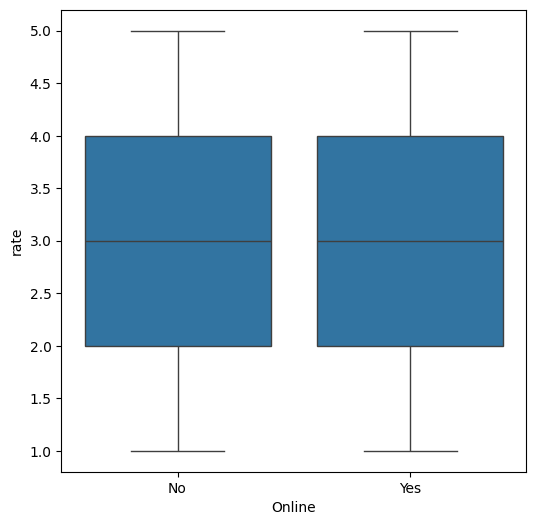

In [36]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'Online', y = 'rate', data = df)

- Both offline and online modes have equal ratings.

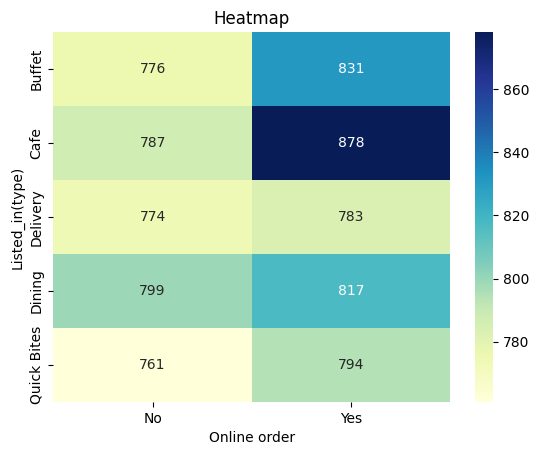

In [38]:
pivot_table = df.pivot_table(index = 'listed_in(type)', columns = 'Online', aggfunc = 'size', fill_value = 0)
sns.heatmap(pivot_table, annot = True, cmap = "YlGnBu", fmt = 'd')
plt.title("Heatmap")
plt.xlabel("Online order")
plt.ylabel("Listed_in(type)")
plt.show()

- Most people prefer online orders at different types of restaurants. And the maximum online orders had been received from cafes.  

# Conclusion:

This project analyzed restaurant data to understand customer preferences and trends. Data cleaning and preprocessing improved accuracy and reliability. Exploratory Data Analysis using Pandas, Matplotlib, and Seaborn helped visualize patterns effectively. It was observed that affordable restaurants are more popular and receive higher customer engagement. Online ordering plays a significant role in attracting customers. Voting patterns indicate customer satisfaction and trust. Different visualizations like count plots, histograms, and heatmaps provided meaningful insights. The project enhanced skills in data analysis, visualization, and problem-solving. Overall, it demonstrated how data-driven insights can help businesses make better decisions and improve customer experience.